# Import thư viện

In [1]:
# =============================================
# IMPORT LIBRARIES
# =============================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import re
import math

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Word Cloud
from wordcloud import WordCloud

# Stats
from scipy import stats
from scipy.stats import mannwhitneyu, linregress

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12

# Download NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


# Load dữ liệu
**Dataset:** [IMDB Dataset of 50K Movie Reviews – Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)  


In [2]:
# =============================================
# LOAD DATA
# =============================================
df = pd.read_csv("../data/raw/IMDB Dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nCác cột: {df.columns.tolist()}")
print(f"\nPhân phối nhãn:\n{df['sentiment'].value_counts()}")
print(f"\n5 dòng đầu:")
df.head()


Shape: (50000, 2)

Các cột: ['review', 'sentiment']

Phân phối nhãn:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

5 dòng đầu:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## NHẬN XÉT - LOAD DỮ LIỆU

---

### Dataset: IMDB Movie Reviews

- Tổng số mẫu: 50,000 reviews  
- Số features: 2 cột  
  - review 
  - sentiment 

---

### Phân phối nhãn

- positive: 25,000 mẫu (50%)  
- negative: 25,000 mẫu (50%)  

---

### Nhận xét

1. Dataset hoàn toàn cân bằng (balanced)  
   → Không cần xử lý imbalance (oversampling / undersampling)

2. Đây là bài toán Binary Classification  
   → Phân loại: positive vs negative

3. Cột review chứa văn bản HTML thô (ví dụ: <"br /">)  
   → Cần được làm sạch (text preprocessing) trước khi xử lý

# Làm sạch dữ liệu ban đầu
- Loại bỏ thẻ HTML, chuẩn hóa khoảng trắng và chuyển về chữ thường để chuẩn bị dữ liệu cho việc phân tích.
- ách từ (tokenization) và tính toán các chỉ số cơ bản như word_count và char_count để phục vụ thống kê mô tả.



In [3]:
def clean_text(text):
    """
    Làm sạch văn bản thô (NHẸ - dùng cho EDA):
    - Loại bỏ HTML tags (vd: <br />, <b>...)
    - Chuẩn hóa khoảng trắng
    - Chuyển về lowercase
    """
    text = re.sub(r'<.*?>', ' ', text)          # remove HTML
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text)            # normalize spaces
    return text

def tokenize(text):
    tokens = word_tokenize(clean_text(text))
    return [t for t in tokens if len(t) > 1] 

def tokenize_all(text):
    tokens = word_tokenize(clean_text(text))
    return [t for t in tokens if len(t) > 1]

# Thêm cột hỗ trợ
df['cleaned']    = df['review'].apply(clean_text)
df['tokens']     = df['cleaned'].apply(tokenize)
df['tokens_all'] = df['cleaned'].apply(tokenize_all)

df['word_count'] = df['tokens_all'].apply(len)
df['char_count'] = df['cleaned'].apply(len)

print("✅ Làm sạch dữ liệu xong!")
print(df[['word_count','char_count']].describe())

✅ Làm sạch dữ liệu xong!
       word_count  char_count
count  50000.0000  50000.0000
mean     226.1972   1286.9038
std      168.9145    972.4275
min        6.0000     32.0000
25%      123.0000    690.0000
50%      169.0000    955.0000
75%      274.0000   1561.0000
max     2399.0000  13593.0000


# EDA Text

## a) Phân phối độ dài văn bản theo nhãn lớp

### Lý thuyết
Phân tích độ dài văn bản giúp trả lời câu hỏi:  
> "Các review positive và negative có xu hướng dài/ngắn khác nhau không?"

Hai đặc trưng được đo:
- **Số từ (word count):** đếm số token sau khi tách từ.
- **Số ký tự (char count):** đếm tổng ký tự sau khi làm sạch (bao gồm cả khoảng trắng).

### Kiểm định Mann-Whitney U
Vì phân phối độ dài thường **lệch phải** (right-skewed), không thỏa giả định chuẩn,  
ta dùng kiểm định **phi tham số Mann-Whitney U** thay cho t-test.

**Giả thuyết:**
$$H_0: \text{Phân phối độ dài của hai lớp là như nhau}$$
$$H_1: \text{Phân phối độ dài của hai lớp khác nhau}$$

**Thống kê kiểm định:**
$$U = \sum_{i=1}^{n_1} \sum_{j=1}^{n_2} S(x_i, y_j), \quad
S(x,y) = \begin{cases} 1 & x > y \\ 0.5 & x = y \\ 0 & x < y \end{cases}$$

**Quyết định:** Nếu $p\text{-value} < 0.05$, bác bỏ $H_0$ — hai lớp có độ dài khác nhau có ý nghĩa thống kê.

Metric                      Positive        Negative
Word Count mean                227.71          224.69
Word Count median              168.00          170.00
Word Count std                 175.11          162.47
-------------------------------------------------------
Char Count mean               1302.94         1270.87
Char Count median              952.00          957.00
Char Count std                1014.34          928.33
-------------------------------------------------------

[Mann-Whitney U] Word Count
  U = 308095410.50 | p-value = 0.006345 → ✅ Có ý nghĩa thống kê

[Mann-Whitney U] Char Count
  U = 310755294.00 | p-value = 0.279633 → ❌ Không có ý nghĩa


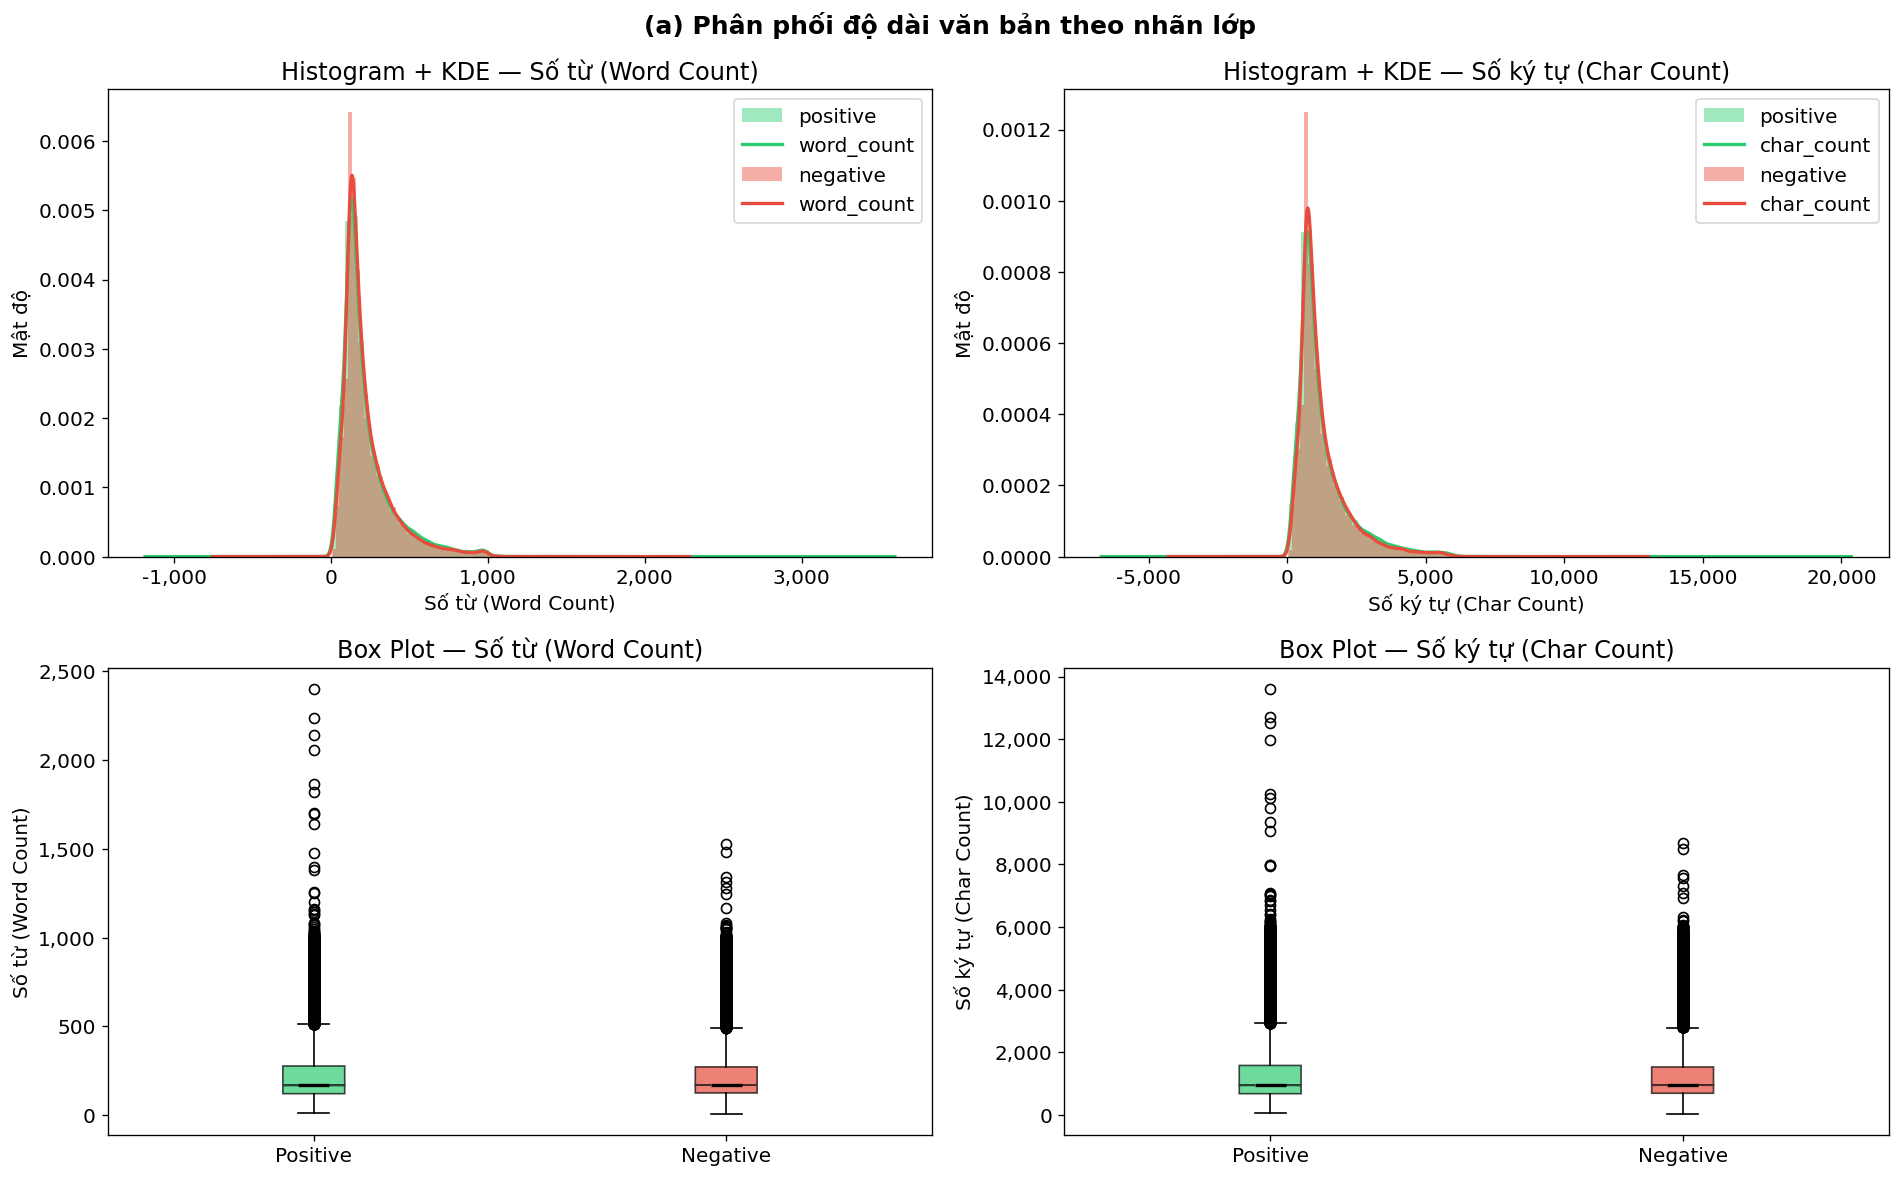

In [4]:
# =============================================
# (a) PHÂN PHỐI ĐỘ DÀI VĂN BẢN
# =============================================
pos = df[df['sentiment'] == 'positive']
neg = df[df['sentiment'] == 'negative']

# ---------- Thống kê mô tả ----------
print("=" * 55)
print(f"{'Metric':<20} {'Positive':>15} {'Negative':>15}")
print("=" * 55)
for metric, col in [("Word Count", "word_count"), ("Char Count", "char_count")]:
    for stat_name, fn in [("mean", np.mean), ("median", np.median), ("std", np.std)]:
        print(f"{metric} {stat_name:<10} {fn(pos[col]):>15.2f} {fn(neg[col]):>15.2f}")
    print("-" * 55)

# ---------- Mann-Whitney U ----------
for label, col in [("Word Count", "word_count"), ("Char Count", "char_count")]:
    u_stat, p_val = mannwhitneyu(pos[col], neg[col], alternative='two-sided')
    sig = "✅ Có ý nghĩa thống kê" if p_val < 0.05 else "❌ Không có ý nghĩa"
    print(f"\n[Mann-Whitney U] {label}")
    print(f"  U = {u_stat:.2f} | p-value = {p_val:.6f} → {sig}")

# ---------- Visualization ----------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("(a) Phân phối độ dài văn bản theo nhãn lớp", fontsize=15, fontweight='bold')

palette = {'positive': '#2ecc71', 'negative': '#e74c3c'}
metrics = [('word_count', 'Số từ (Word Count)'), ('char_count', 'Số ký tự (Char Count)')]

for col_idx, (col, title) in enumerate(metrics):
    # Histogram + KDE
    ax = axes[0, col_idx]
    for sentiment, color in palette.items():
        subset = df[df['sentiment'] == sentiment][col]
        ax.hist(subset, bins=60, alpha=0.45, color=color, label=sentiment, density=True)
        subset.plot.kde(ax=ax, color=color, linewidth=2)
    ax.set_title(f'Histogram + KDE — {title}')
    ax.set_xlabel(title)
    ax.set_ylabel('Mật độ')
    ax.legend()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Box plot
    ax2 = axes[1, col_idx]
    data_box = [pos[col].values, neg[col].values]
    bp = ax2.boxplot(data_box, patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_xticklabels(['Positive', 'Negative'])
    ax2.set_title(f'Box Plot — {title}')
    ax2.set_ylabel(title)
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

### Phân tích và nhận xét phần a

Sau khi tính toán và trực quan hóa độ dài văn bản theo hai chỉ số **số từ (Word Count)** và **số ký tự (Char Count)**, ta nhận thấy:

- Phân phối của cả hai lớp **Positive** và **Negative** đều có dạng **lệch phải mạnh (right-skewed)**  
- Hầu hết các văn bản có độ dài **tương đối ngắn**:
  - Dưới **500 từ**
  - Dưới **3000 ký tự**
- Một số ít văn bản là **outliers** với độ dài rất lớn:
  - Hơn **2000 từ**
  - Hơn **12000 ký tự**

---

#### Thống kê mô tả

- **Lớp Positive** có độ dài trung bình cao hơn lớp **Negative** ở cả hai chỉ số:
  - **Word Count (mean):** 227.71 so với 224.69  
  - **Char Count (mean):** 1302.94 so với 1270.87  

- **Trung vị (median):**
  - Số từ: **168 so với 170**  
  - Số ký tự: **gần như tương đương**

---

#### Kiểm định thống kê

Để kiểm tra sự khác biệt có ý nghĩa thống kê giữa hai lớp, sử dụng:

> **Mann-Whitney U test** *(kiểm định phi tham số, phù hợp với dữ liệu không tuân theo phân phối chuẩn)*

- **Word Count:**
  - **p-value = 0.006345 < 0.05**
  - → **Có sự khác biệt có ý nghĩa thống kê**
  - → Văn bản lớp **Positive** có xu hướng **dài hơn** lớp **Negative** về số từ

- **Char Count:**
  - **p-value = 0.279633 > 0.05**
  - → **Không có sự khác biệt có ý nghĩa thống kê**

---

#### Kết luận

- Sự khác biệt về **trung bình** là **không lớn**
- Tuy nhiên, xét theo **số lượng từ**:
  - Văn bản mang cảm xúc **tích cực (Positive)** có xu hướng **dài hơn đáng kể**
- Điều này cho thấy:
  - Người dùng khi bày tỏ cảm xúc tích cực thường có xu hướng **viết chi tiết, dài dòng hơn**

## b) Word Cloud & Top-50 từ phổ biến + Type-Token Ratio (TTR)

### Word Cloud
Word Cloud là biểu đồ trực quan hóa tần suất từ:  
từ càng **xuất hiện nhiều** → hiển thị càng **to** và **đậm**.  
Giúp nhanh chóng nhận ra các từ đặc trưng cho từng nhãn cảm xúc.

### Top-50 từ phổ biến
Đếm tần suất từ (sau khi loại stopwords) và lấy 50 từ cao nhất mỗi lớp.  
Bảng và biểu đồ bar cho thấy sự khác biệt từ vựng giữa positive vs negative.

### Type-Token Ratio (TTR)
TTR đo lường **độ phong phú từ vựng** của một văn bản/tập văn bản:

$$\text{TTR} = \frac{|V|}{N}$$

Trong đó:
- $|V|$ = số từ **duy nhất** (types — vocabulary size)  
- $N$ = tổng số từ (tokens)  
- $\text{TTR} \in (0, 1]$: càng gần 1 → từ vựng càng phong phú, ít lặp lại


TTR — Positive : 0.018253
TTR — Negative : 0.017929
→ Positive có từ vựng phong phú hơn
       Lớp      TTR Số từ duy nhất (V) Tổng tokens (N)
  Positive  0.01825             103908         5692705
  Negative  0.01793             100712         5617157
Chênh lệch +0.00032                  —               —


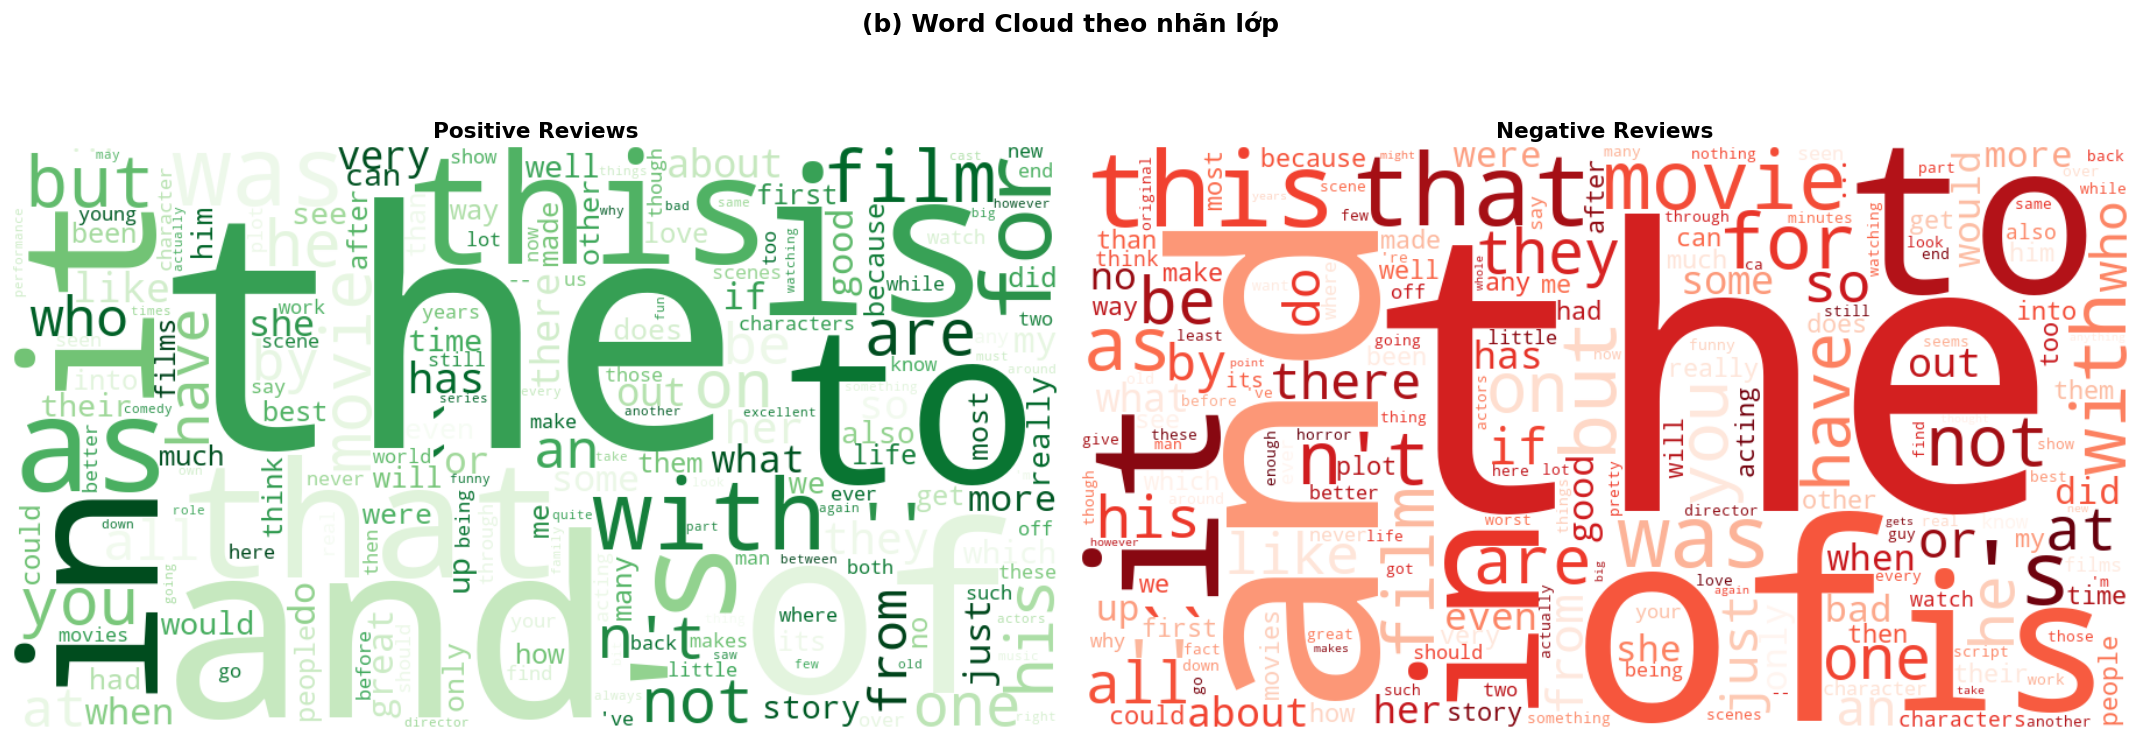

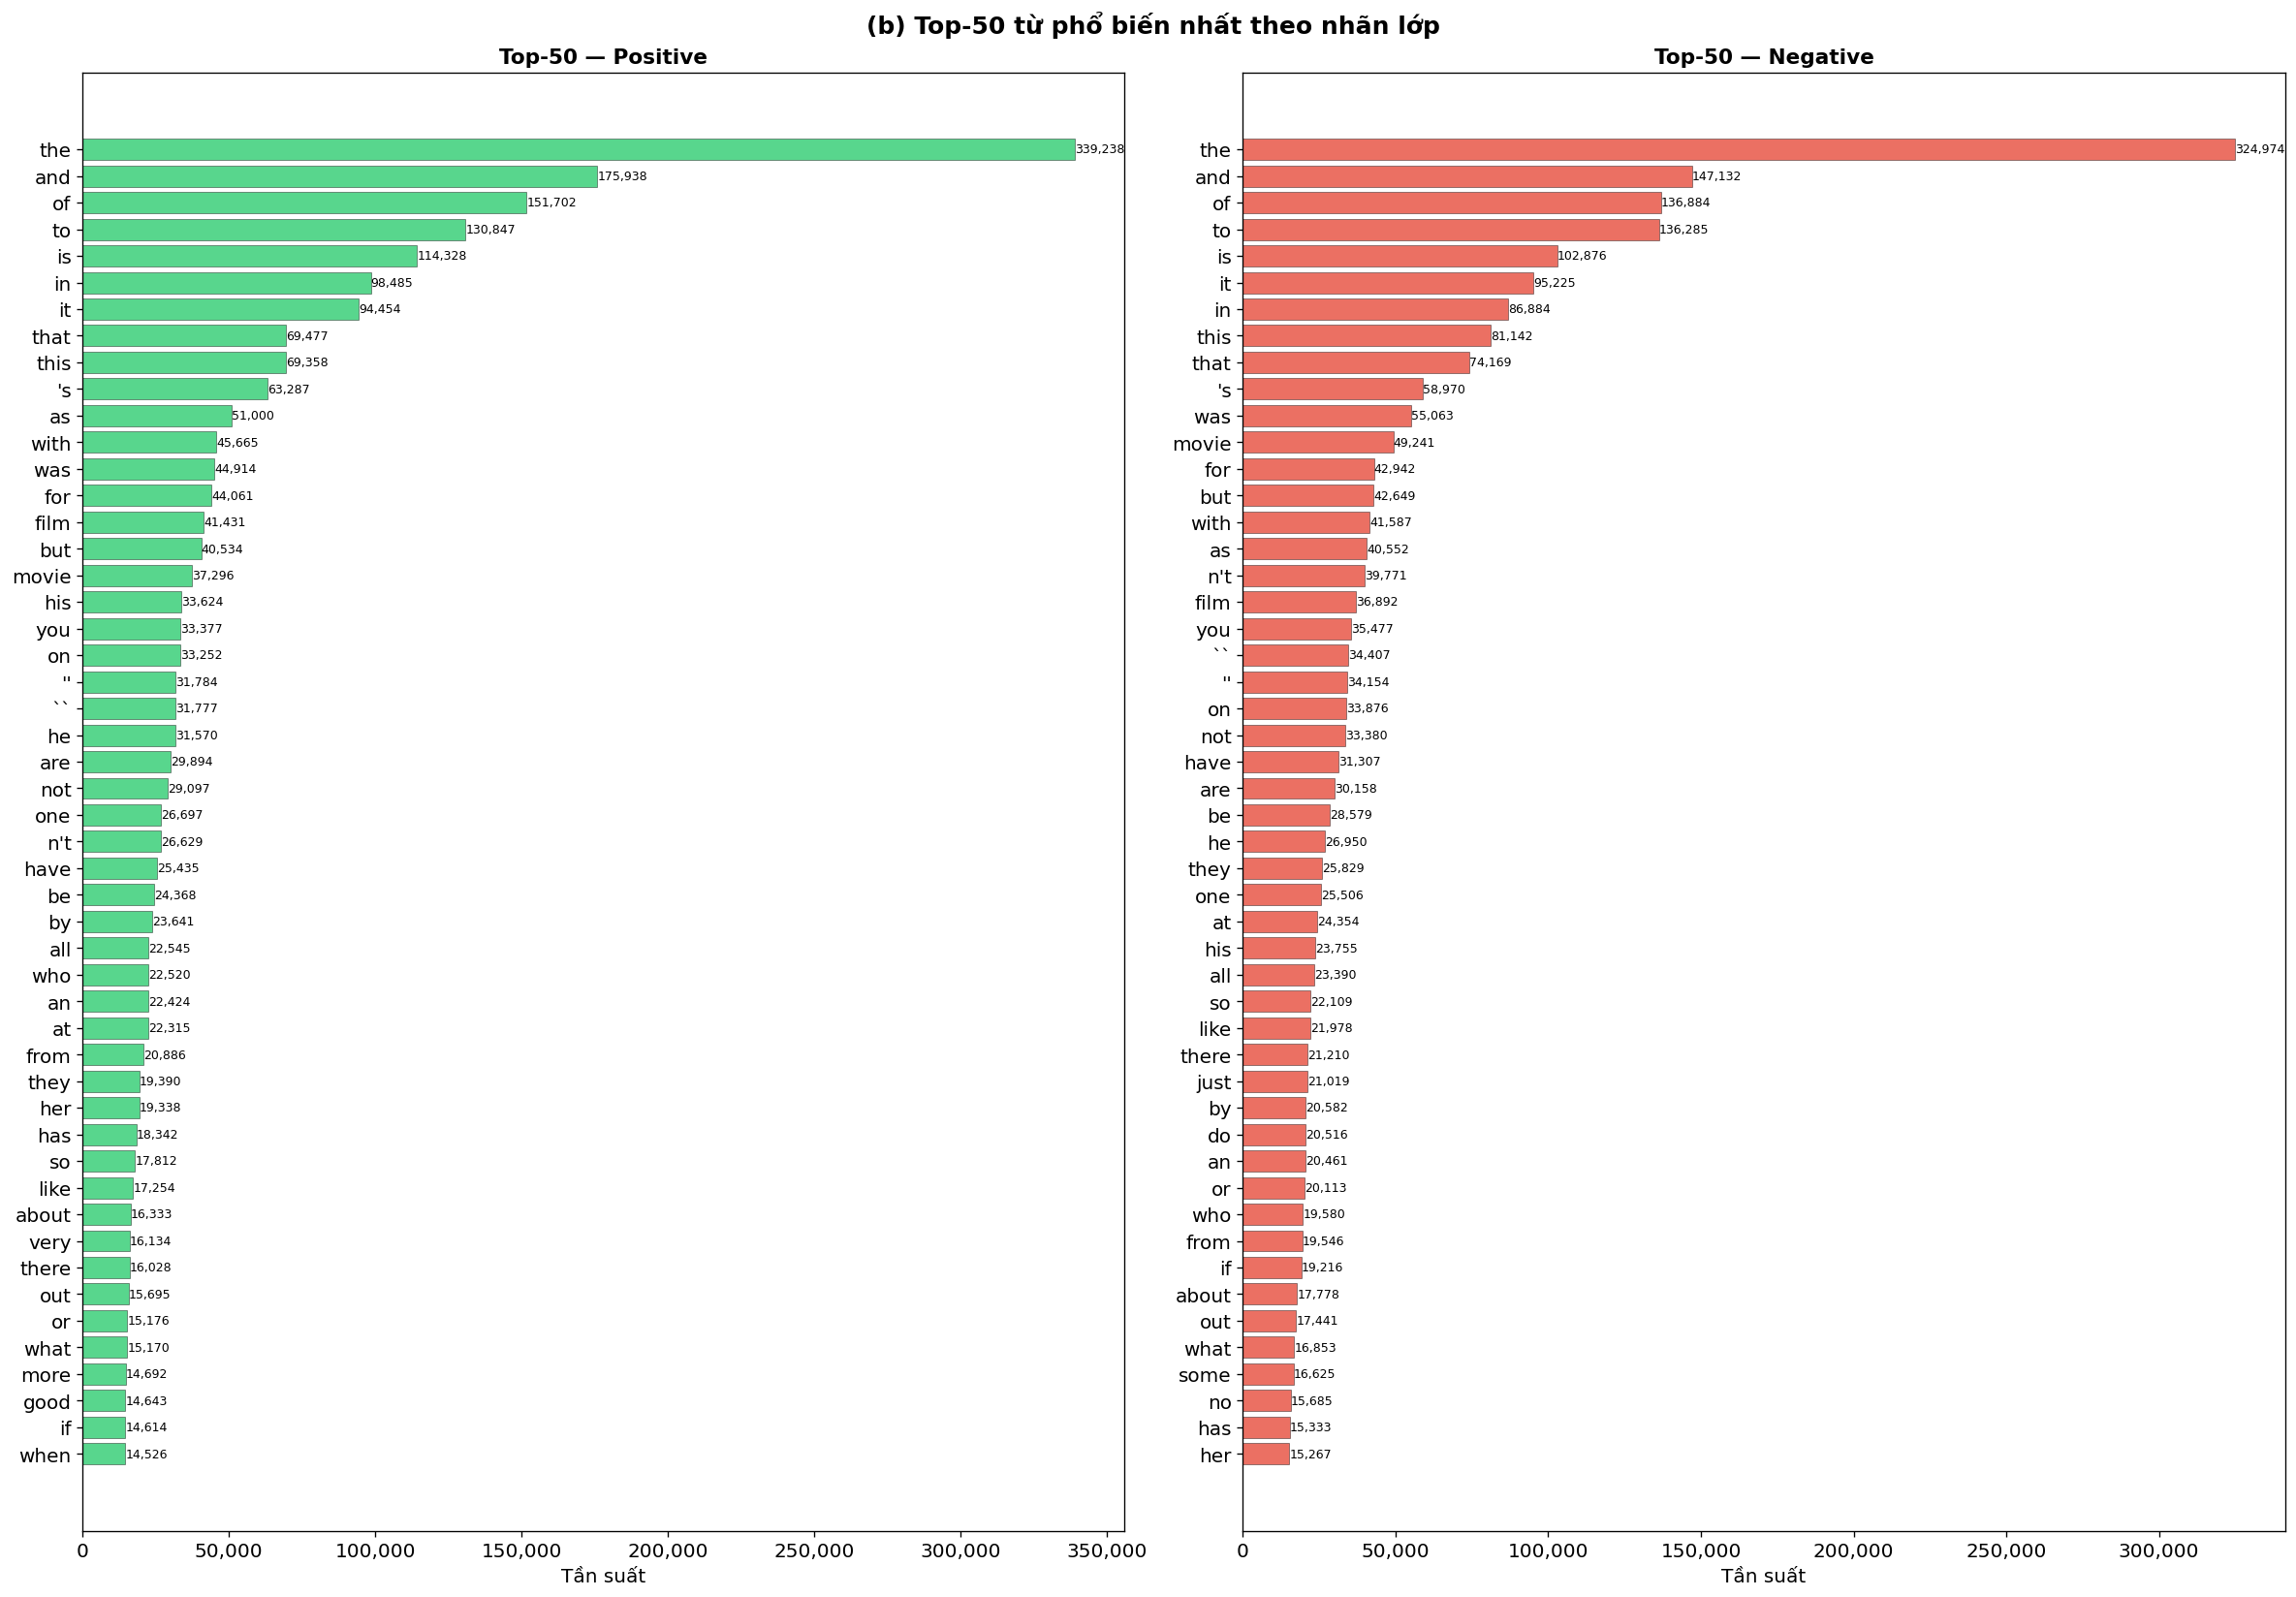


 Bảng Top-50 từ phổ biến:
 Rank Positive Word  Positive Freq Negative Word  Negative Freq
    1           the         339238           the         324974
    2           and         175938           and         147132
    3            of         151702            of         136884
    4            to         130847            to         136285
    5            is         114328            is         102876
    6            in          98485            it          95225
    7            it          94454            in          86884
    8          that          69477          this          81142
    9          this          69358          that          74169
   10            's          63287            's          58970
   11            as          51000           was          55063
   12          with          45665         movie          49241
   13           was          44914           for          42942
   14           for          44061           but          42649
   15        

In [5]:
# =============================================
# (b) WORD CLOUD + TOP-50 + TTR
# =============================================

# ---------- Gộp tokens theo class ----------
tokens_pos = [tok for toks in pos['tokens'] for tok in toks]
tokens_neg = [tok for toks in neg['tokens'] for tok in toks]

freq_pos = Counter(tokens_pos)
freq_neg = Counter(tokens_neg)

top50_pos = freq_pos.most_common(50)
top50_neg = freq_neg.most_common(50)

# ---------- TTR ----------
def compute_ttr(token_list):
    N = len(token_list)
    V = len(set(token_list))
    return V / N if N > 0 else 0

ttr_pos = compute_ttr(tokens_pos)
ttr_neg = compute_ttr(tokens_neg)
print(f"TTR — Positive : {ttr_pos:.6f}")
print(f"TTR — Negative : {ttr_neg:.6f}")
print(f"→ {'Positive' if ttr_pos > ttr_neg else 'Negative'} có từ vựng phong phú hơn")
ttr_df = pd.DataFrame({
    'Lớp'              : ['Positive', 'Negative', 'Chênh lệch'],
    'TTR'              : [f'{ttr_pos:.5f}', f'{ttr_neg:.5f}', f'{ttr_pos - ttr_neg:+.5f}'],
    'Số từ duy nhất (V)': [len(set(tokens_pos)), len(set(tokens_neg)), '—'],
    'Tổng tokens (N)'  : [len(tokens_pos), len(tokens_neg), '—'],
})
print(ttr_df.to_string(index=False))
# ---------- Word Cloud ----------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("(b) Word Cloud theo nhãn lớp", fontsize=15, fontweight='bold')

for ax, (freq, label, cmap) in zip(axes, [
    (freq_pos, 'Positive', 'Greens'),
    (freq_neg, 'Negative', 'Reds')
]):
    wc = WordCloud(
        width=900, height=500,
        background_color='white',
        colormap=cmap,
        max_words=200,
        collocations=False
    ).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{label} Reviews', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# ---------- Top-50 Bar chart ----------
fig, axes = plt.subplots(1, 2, figsize=(20, 14))
fig.suptitle("(b) Top-50 từ phổ biến nhất theo nhãn lớp", fontsize=15, fontweight='bold')

for ax, (top50, label, color) in zip(axes, [
    (top50_pos, 'Positive', '#2ecc71'),
    (top50_neg, 'Negative', '#e74c3c')
]):
    words, counts = zip(*top50)
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.8, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top-50 — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tần suất')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for i, (w, c) in enumerate(zip(words[::-1], counts[::-1])):
        ax.text(c + 50, i, f'{c:,}', va='center', fontsize=7.5)

plt.tight_layout()
plt.show()

# ---------- Bảng Top-50 ----------
df_top50 = pd.DataFrame({
    'Rank': range(1, 51),
    'Positive Word': [w for w, _ in top50_pos],
    'Positive Freq': [c for _, c in top50_pos],
    'Negative Word': [w for w, _ in top50_neg],
    'Negative Freq': [c for _, c in top50_neg],
})
print("\n Bảng Top-50 từ phổ biến:")
print(df_top50.to_string(index=False))

### Phân tích và nhận xét phần b

Nhóm đã xây dựng **Word Cloud** và bảng **Top-50 từ có tần suất xuất hiện cao nhất** cho từng lớp. Kết quả cho thấy:

- Cả hai lớp **Positive** và **Negative** đều có những **từ chức năng (stopwords)** chiếm ưu thế tuyệt đối  
- Các từ điển hình bao gồm: *“the”, “and”, “of”, “to”, “is”, “in”, “it”*  
- Điều này là **bình thường** trong dữ liệu văn bản tiếng Anh **chưa loại bỏ stopwords**

---

#### So sánh các từ mang nội dung (content words)

Khi quan sát các từ mang nội dung, nhóm nhận thấy một số sự khác biệt rõ nét giữa hai lớp:

- **Trong lớp Positive:**
  - Xuất hiện nhiều từ mang tính **khen ngợi và cảm xúc tích cực**
  - Ví dụ: *film, movie, great, love, best, well, excellent*

- **Trong lớp Negative:**
  - Các từ mang tính **phủ định và tiêu cực** nổi bật hơn
  - Ví dụ: *not, but, no, bad, worst, didn’t (n’t), waste*

---

#### Quan sát từ bảng Top-50

- Tần suất của từ *“the”* ở lớp **Negative** **cao hơn đáng kể** so với lớp **Positive**  
- Ngược lại, một số từ tích cực như *“good”, “more”* xuất hiện trong **top cao** của lớp **Positive**

---

#### Độ phong phú từ vựng (Type-Token Ratio - TTR)

- **TTR Positive:** 0.018253  
- **TTR Negative:** 0.017929  

Kết quả cho thấy:

- Lớp **Positive** có từ vựng **phong phú hơn** so với lớp **Negative**  
- Mức chênh lệch: **+0.000324**

Điều này ngụ ý rằng:

- Các đánh giá mang cảm xúc **tích cực** thường sử dụng **đa dạng từ ngữ hơn một chút**  
- So với các đánh giá mang cảm xúc **tiêu cực**

---

#### Kết luận

Tóm lại, qua **Word Cloud** và bảng **Top-50 từ**:

- Mặc dù **stopwords chiếm đa số**,  
- Hai lớp vẫn thể hiện rõ sự khác biệt về **từ ngữ mang tính cảm xúc**

Cụ thể:

- **Lớp Positive:** sử dụng nhiều từ mang ý nghĩa **khen ngợi và tích cực**  
- **Lớp Negative:** sử dụng nhiều từ **phủ định** và thể hiện **sự không hài lòng**

## c) Phân tích phân phối Zipf

### Định luật Zipf
Định luật Zipf (George Kingsley Zipf, 1949) phát biểu:

> Trong ngôn ngữ tự nhiên, tần suất của một từ **tỉ lệ nghịch** với hạng (rank) của nó.

$$f(r) = \frac{C}{r^{\alpha}}$$

Trong đó:
- $f(r)$ = tần suất của từ ở hạng $r$
- $r$ = hạng từ (rank), từ phổ biến nhất có $r=1$
- $\alpha \approx 1$ (hệ số Zipf lý tưởng)
- $C$ = hằng số chuẩn hóa

### Log-log plot
Lấy $\log$ hai vế:

$$\log f(r) = \log C - \alpha \cdot \log r$$

Đây là phương trình **đường thẳng** trên không gian log-log với **độ dốc** $= -\alpha$.  
Nếu dữ liệu thực tế gần với đường thẳng này → tuân theo định luật Zipf.

### Đánh giá mức độ tuân theo
- Dùng **hồi quy tuyến tính (OLS)** trên log-log để ước lượng $\hat{\alpha}$ và $R^2$
- $|\hat{\alpha} - 1|$ càng nhỏ và $R^2$ càng gần 1 → càng tuân theo Zipf

Metric                         Positive           Negative
α (Zipf exponent)                1.5241
R²                               0.9723
p-value (OLS)                  0.000000
------------------------------------------------------------
α (Zipf exponent)                1.5056
R²                               0.9743
p-value (OLS)                  0.000000
------------------------------------------------------------

 Tóm tắt:
  positive  : α = 1.5241 | R² = 0.9723 | |α-1| = 0.5241
  negative  : α = 1.5056 | R² = 0.9743 | |α-1| = 0.5056


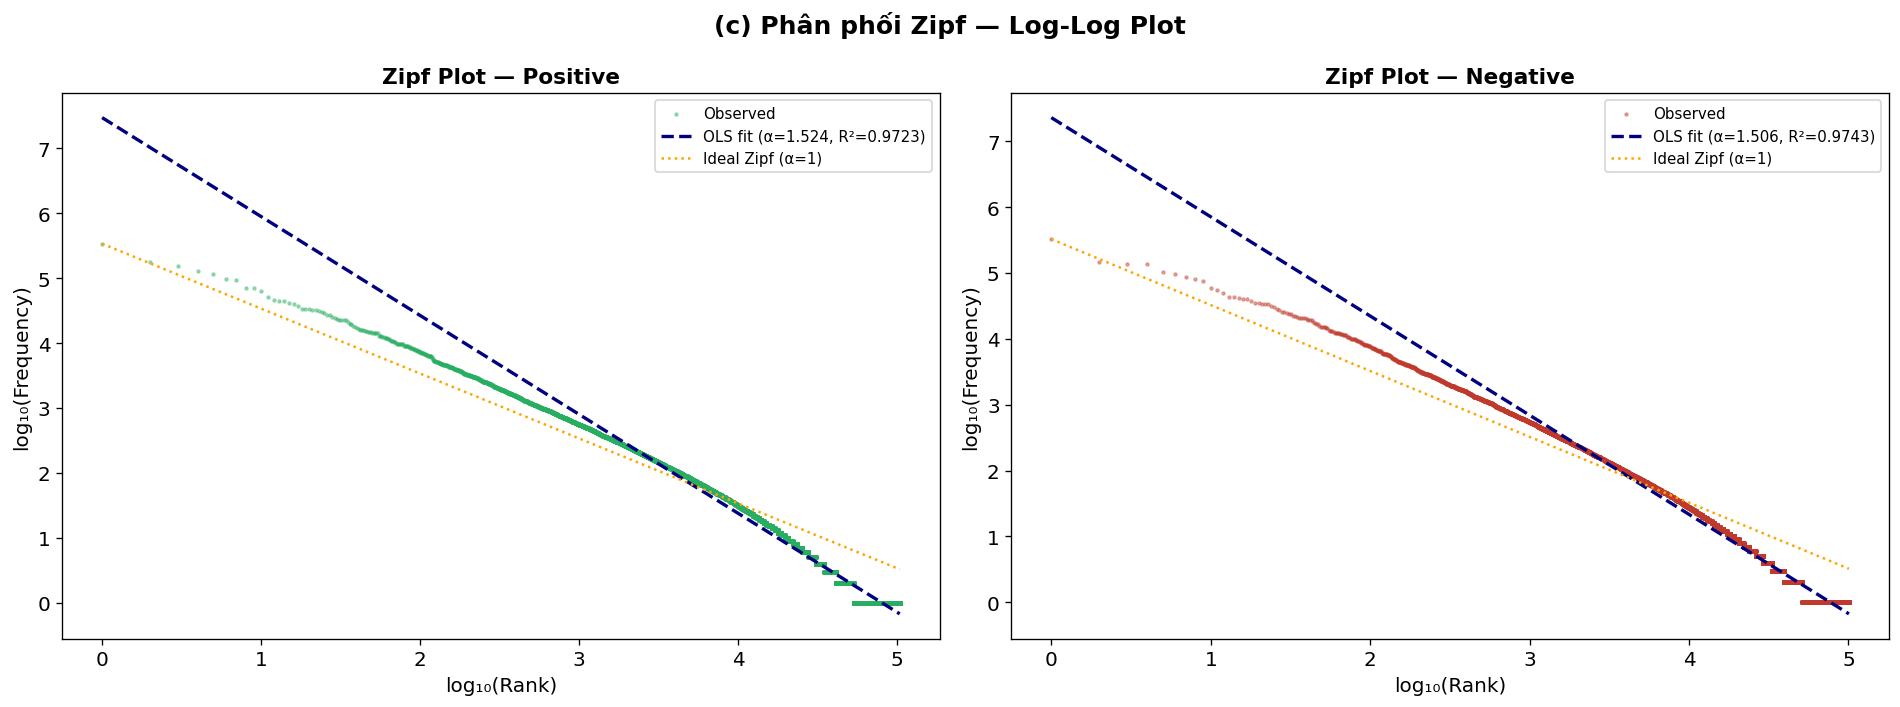

In [6]:
# =============================================
# (c) PHÂN TÍCH PHÂN PHỐI ZIPF
# =============================================

def zipf_analysis(token_list, label, color, ax):
    freq = Counter(token_list)
    # Sắp xếp giảm dần theo tần suất
    sorted_freq = sorted(freq.values(), reverse=True)
    ranks  = np.arange(1, len(sorted_freq) + 1)
    counts = np.array(sorted_freq)

    log_r = np.log10(ranks)
    log_f = np.log10(counts)

    # OLS trên log-log
    slope, intercept, r_value, p_value, std_err = linregress(log_r, log_f)

    # Zipf lý tưởng (alpha = 1)
    ideal_zipf = np.log10(counts[0]) - log_r  # log C - 1*log(r)

    # Plot
    ax.scatter(log_r, log_f, s=3, alpha=0.4, color=color, label='Observed')
    ax.plot(log_r, intercept + slope * log_r, color='navy',
            linewidth=2, linestyle='--', label=f'OLS fit (α={-slope:.3f}, R²={r_value**2:.4f})')
    ax.plot(log_r, ideal_zipf, color='orange',
            linewidth=1.5, linestyle=':', label='Ideal Zipf (α=1)')

    ax.set_title(f'Zipf Plot — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('log₁₀(Rank)')
    ax.set_ylabel('log₁₀(Frequency)')
    ax.legend(fontsize=9)

    return slope, r_value**2, p_value

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("(c) Phân phối Zipf — Log-Log Plot", fontsize=15, fontweight='bold')

print("=" * 60)
print(f"{'Metric':<20} {'Positive':>18} {'Negative':>18}")
print("=" * 60)

results = {}
for ax, (token_list, label, color, key) in zip(axes, [
    (tokens_pos, 'Positive', '#27ae60', 'positive'),
    (tokens_neg, 'Negative', '#c0392b', 'negative'),
]):
    slope, r2, pval = zipf_analysis(token_list, label, color, ax)
    results[key] = {'alpha': -slope, 'R2': r2}
    print(f"α (Zipf exponent)    {results['positive']['alpha'] if key=='positive' else results['negative']['alpha']:>18.4f}")
    print(f"R²                   {r2:>18.4f}")
    print(f"p-value (OLS)        {pval:>18.6f}")
    print("-" * 60)

# In lại gọn
print("\n Tóm tắt:")
for k, v in results.items():
    diff = abs(v['alpha'] - 1)
    print(f"  {k:10s}: α = {v['alpha']:.4f} | R² = {v['R2']:.4f} | |α-1| = {diff:.4f}")

plt.tight_layout()
plt.show()

### Phân tích và nhận xét phần c

Nhóm đã vẽ biểu đồ **log-log plot** của **tần suất từ (log₁₀ Frequency)** theo **thứ hạng từ (log₁₀ Rank)** cho cả hai lớp **Positive** và **Negative**, đồng thời thực hiện **hồi quy tuyến tính (OLS)** để ước lượng **hệ số Zipf (α)**.

---

#### Kết quả hồi quy

- **Lớp Positive:**
  - α = 1.5241  
  - R² = 0.9723  

- **Lớp Negative:**
  - α = 1.5056  
  - R² = 0.9743  

---

#### Đánh giá độ phù hợp

- Cả hai mô hình đều có **hệ số xác định R² rất cao (> 0.97)**  
- → Cho thấy phân phối tần suất từ trong dữ liệu **tuân theo định luật Zipf ở mức độ tốt**  

- Đường hồi quy *(đường màu xanh dương)*:
  - Nằm **sát với dữ liệu quan sát**
  - Đặc biệt ở **phần giữa** và **phần đuôi** của biểu đồ  

---

#### So sánh với Zipf lý tưởng

- **Zipf lý tưởng:** α = 1 *(đường màu vàng chấm)*  

- **Sai lệch so với lý tưởng:**
  - Positive: |α - 1| = 0.5241  
  - Negative: |α - 1| = 0.5056  

→ Cả hai lớp đều có **α > 1**, cho thấy:

- Phân phối **không hoàn toàn lý tưởng**
- Có xu hướng **dốc hơn (steeper slope)**

Điều này có nghĩa là:

- Một số từ **cực kỳ phổ biến** (*“the”, “and”, “of”*) xuất hiện với tần suất **cao hơn nhiều** so với dự đoán của Zipf chuẩn  
- Trong khi đó, **phần lớn các từ còn lại** có tần suất **giảm nhanh hơn**

---

#### So sánh giữa hai lớp

- Giá trị **α của lớp Positive cao hơn một chút** so với lớp Negative  
- → Cho thấy trong các đánh giá **tích cực**:
  - Sự chênh lệch tần suất giữa **từ phổ biến nhất** và **các từ hiếm** rõ rệt hơn  

- Tuy nhiên:
  - **Sự khác biệt là không lớn**

---

#### Kết luận

- Dữ liệu văn bản ở cả hai lớp đều **tuân thủ khá tốt định luật Zipf**  
- Mức độ phù hợp cao với:
  - **R² > 0.97**

- Việc **α > 1** phản ánh đặc trưng thường gặp trong:
  - **corpus tiếng Anh thực tế**

→ Nơi một nhóm nhỏ **từ chức năng (stopwords)** chiếm ưu thế tuyệt đối về tần suất